# Versuch 3

## Aufgabe 3.1

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

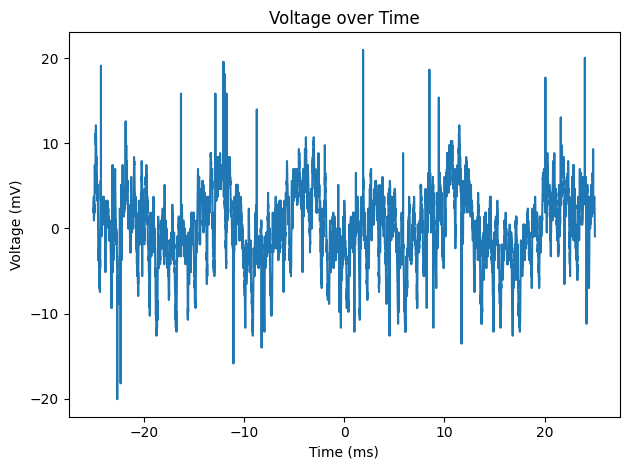

Abtastintervall: 0.005 ms
Abtastfrequenz: 200000.00 Hz
Signallänge: 10004
Signaldauer: 50.01 ms
Grundperiode: 0.097 ms
Grundfrequenz: 10359.047 Hz


In [99]:
df = pd.read_csv("Versuch3-1_harmonica/Versuch3-1_harmonica_22.csv", delimiter=";", decimal=",", skiprows=[1])
plt.plot(df["Zeit"], df["Kanal A"])
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Voltage over Time")
plt.tight_layout()
plt.show()

t = df["Zeit"].values
ts = t / 1000.0 # Convert to seconds
v = df["Kanal A"].values

dt = ts[1] - ts[0]
dts = dt / 1000 # Convert dt to seconds
fs = 1.0 / dt
M = len(v)
T = ts[-1] - ts[0]

print(f"Abtastintervall: {dt * 1000:.3f} ms\nAbtastfrequenz: {fs:.2f} Hz\nSignallänge: {M}\nSignaldauer: {T * 1000:.2f} ms")

peaks, _ = find_peaks(v, height=np.mean(v) + np.std(v))

T0_est = np.diff(ts[peaks])
T0 = np.mean(T0_est)

F0 = 1 / T0

print(f"Grundperiode: {T0 * 1000:.3f} ms\nGrundfrequenz: {F0:.3f} Hz")


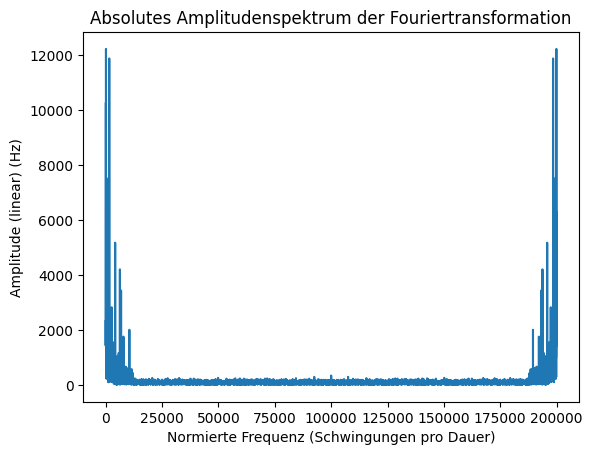

Wellenzahl: 621
Grundfrequenz: 12415.033986401637 Hz
Amplitude: 0.00012546560093716784
1039.6881197642115


In [100]:
fft = np.fft.fft(v)
fft_abs = np.abs(fft)
freqs = np.fft.fftfreq(M, dts)
k = np.arange(M)
k = k / T
idx = freqs > 0
freqs_pos = freqs[idx]
fft_pos = fft[idx]

A = 2.0 / (M * np.abs(fft_pos))

k0 = np.argmax(A)
f0 = k0 / (M * dt)
A0 = A[k0]

plt.plot(k,fft_abs)
plt.xlabel("Normierte Frequenz (Schwingungen pro Dauer)")
plt.ylabel("Amplitude (linear) (Hz)")
plt.title("Absolutes Amplitudenspektrum der Fouriertransformation")
plt.show()

print(f"Wellenzahl: {k0}\nGrundfrequenz: {f0} Hz\nAmplitude: {A0}")

print(k[np.argmax(fft[0:5000])])

## Aufgabe 3.2

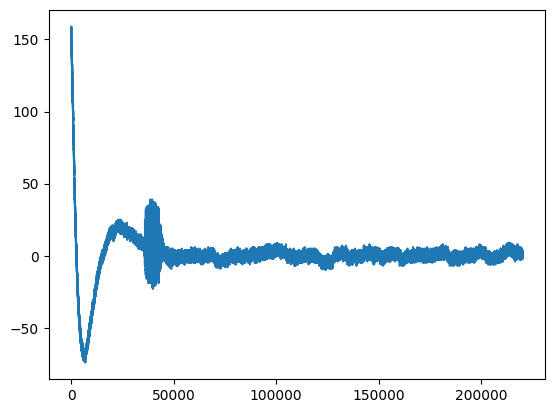

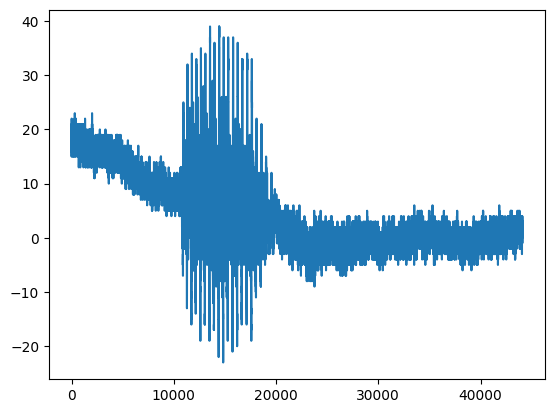

In [101]:
SAMPLE_FILE = "./versuch3-3/hoch_t1_0.npy"

audio = np.load(SAMPLE_FILE)
plt.plot(audio)
rate = 44100 # sampling rate per second
audio_trimmed = audio[25000 : 25000 + rate] # Sample trimmed down to a second

plt.show()
plt.plot(audio_trimmed)
plt.show()

A: [8.09800454e+00 6.84712090e+00 2.47351303e+00 ... 4.73937566e-03
 2.18006259e-03 3.16465076e-03]


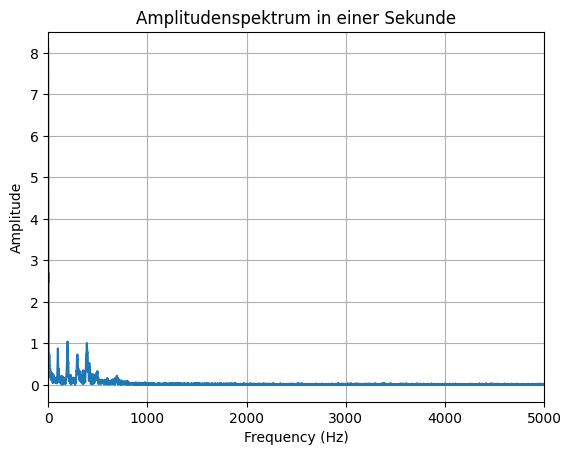

k0 0
Grundfrequenz: 0.0 Hz
Amplitude: 0.00012546560093716784


In [102]:
N = len(audio_trimmed)
dt = 1 / rate
k = np.arange(M)


ft = np.fft.fft(audio_trimmed)
freqs = np.fft.fftfreq(N, dt)
idx = freqs >= 0
freqs_pos = freqs[idx]

A = 2.0 / N * np.abs(ft[idx])
ft_abs = np.abs(ft)

print("A:",A)

plt.plot(freqs_pos, A)
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitudenspektrum in einer Sekunde")
plt.grid(True)
plt.show()

k0 = np.argmax(A)
print("k0",k0)
f0 = freqs_pos[k0]
A9 = A[k0]

print(f"Grundfrequenz: {f0} Hz\nAmplitude: {A0}")